# Temporal component — probabilistic rainfall thresholds (Chapter 6, Results)

Figures, tables and numbers of `\subsection{Rainfall thresholds}` (`sec:res-gam`), read from the
outputs of **`gam_umbrales_cap6.py`** (GAM with the sampling design C of Chapter 5, 100 Monte
Carlo runs). The notebook does **not** refit anything and does not need pyGAM: the model is
additive on the logit scale,

$$\operatorname{logit}(p) = \alpha + s_1(\mathrm{STR}_1) + s_2(\mathrm{LTR}_{30}) + \gamma_{\mathrm{ENSO}} + \delta_{\mathrm{zone}} + \eta_{\mathrm{type}},$$

and the script saves every term of every run on fixed grids, so any probability surface is
rebuilt exactly by adding rows of the effects table (section 2 checks it against the saved
predictions).

| Outline | Output | Kind |
|---|---|---|
| sample | `tabla_res_gam_muestra` | table: records kept at each step, landslides per level |
| (a) | `tabla_res_gam_desempeno`, `fig_gam_desempeno` | table + boxplots over the runs |
| (b)–(c) | `fig_gam_efectos`, `tabla_res_gam_factores` | partial effects: final model + spread of the runs |
| (d) | `tabla_res_gam_cortes`, `tabla_res_gam_clases`, `fig_gam_roc_calibracion` | cut-offs with TPR/FPR, the four rainfall classes, ROC + reliability |
| (e) | `fig_gam_isolineas`, `tabla_res_gam_umbrales_mm` | zone × ENSO panels with the three cut-offs; rainfall needed to reach each class |

Figures go to `00Figuras/06Seccion` (PDF + PNG) and tables to `salidas/` (CSV); each table
cell also prints its LaTeX.

**Design rules** (same as the other Chapter 6 notebooks): no panel titles, letters in the
upper-left corner, 9 pt text at print size (16.5 cm wide), and the four rainfall classes in the
hues of the decision matrix (green, amber, orange, red).

**Which model draws what** (Methods, `sec:th-gam-thr`): the cut-offs are the median over the
runs; the effects, the contour lines and the rainfall table use the final model (the run with
the median AUROC, refitted on its whole sample), and the spread over the runs is shown next to it.

> **Diseño de las ausencias.** El script escribe cada configuración en su propia subcarpeta de
> `Umbrales/` (`excl10d_libre`: ±10 días de cada deslizamiento y fecha libre; `excl0d_anomes`:
> set C del Cap. 5). Elige cuál leer con `DISENO` en la celda de configuración; las figuras y
> tablas llevan ese sufijo para poder compararlas.
>
> Cambios que exigen volver a correr el script (no este notebook solo): `EXCL_DAYS_C`,
> `MATCH_TIME`, `LTR_DEF`, `N_SPLINES`, `DEDUP`, `SPLIT` o `FECHA_CORTE`. Si reajustas M1
> (M1_train), cambia el dominio y también hay que volver a correrlo.

## 1. Libraries and settings

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex, to_rgb
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Polygon as MplPolygon

warnings.filterwarnings('ignore', category=UserWarning)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
})

# ---------------------------------------------------------------- paths
DISENO  = 'excl10d_libre'      # subcarpeta del diseño a leer: 'excl10d_libre' | 'excl0d_anomes'
UMB_DIR = Path('/home/oisanchezp/Thesis/src/06_Chapter/Umbrales') / DISENO   # salidas de gam_umbrales_cap6.py
SUF     = f'_{DISENO}'         # sufijo de figuras y tablas (quítalo cuando elijas el diseño final)
FIG_DIR = Path('00Figuras/06Seccion')
TAB_DIR = Path('salidas')
TAG = 'gam_cap6'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)
WIDTH = 6.5          # in, ancho de impresión (16.5 cm)

# ---------------------------------------------------------------- labels (verifica los nombres de zona)
ZONE_LABEL = {'1': 'Oriente', '2': 'Norte', '3': 'Sur', '4': 'SAP', '5': 'Occidente'}
ENSO_ORDER = ['La Niña', 'Neutro', 'El Niño']
ENSO_LABEL = {'La Niña': 'La Niña', 'Neutro': 'Neutral', 'El Niño': 'El Niño'}
def TYPE_LABEL(t):
    return f'Type {t}'

CLASSES = ['Low', 'Moderate', 'High', 'Very high']
LEVEL_KEY = {'Moderate': 'P_TPR95', 'High': 'P_TPR85', 'Very high': 'P_TPR70'}   # corte que abre cada clase
KEY_LABEL = {'P_TPR95': '$P^*_{95}$', 'P_TPR85': '$P^*_{85}$', 'P_TPR70': '$P^*_{70}$',
             'P_OPT': 'Youden'}

# ---------------------------------------------------------------- colours (hues of the decision matrix)
def tint(c, t):
    """Mezcla con blanco: t = 1 color puro, t = 0 blanco."""
    return to_hex([t * v + (1 - t) for v in to_rgb(c)])

def shade(c, t):
    """Mezcla con negro: t = 1 color puro."""
    return to_hex([t * v for v in to_rgb(c)])

BASE = {'Low': '#2E7D32', 'Moderate': '#F9A825', 'High': '#EF6C00', 'Very high': '#C62828'}
FILL = {k: tint(c, 0.42) for k, c in BASE.items()}     # bandas de clase
LINE = {k: shade(c, 0.72) for k, c in BASE.items()}    # líneas de corte y puntos
INK, MUTED = '#1a1a19', '#6b6b6b'
GAM_COLOR = '#1f5f8b'
RUNS_COLOR = '0.78'

# ---------------------------------------------------------------- helpers
def q05(x):
    return float(np.nanpercentile(np.asarray(x, float), 5))

def q95(x):
    return float(np.nanpercentile(np.asarray(x, float), 95))

def med_rng(x, fmt='{:.3f}'):
    """'mediana [P5-P95]' de una serie de corridas."""
    x = np.asarray(x, float)
    return f"{fmt.format(np.nanmedian(x))} [{fmt.format(q05(x))}–{fmt.format(q95(x))}]"

def letter(ax, s, x=0.025, y=0.975, box=False):
    ax.text(x, y, f'({s})', transform=ax.transAxes, ha='left', va='top', fontsize=9,
            fontweight='bold', color=INK, zorder=10,
            bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=.8) if box else None)

def frame(ax):
    for sp in ax.spines.values():
        sp.set_linewidth(0.6)
        sp.set_color('0.35')

def savefig(fig, name):
    for ext in ('pdf', 'png'):
        fig.savefig(FIG_DIR / f'{name}{SUF}.{ext}', dpi=300, bbox_inches='tight', facecolor='white')
    print('guardada:', FIG_DIR / f'{name}{SUF}.pdf')

def expit(z):
    return 1.0 / (1.0 + np.exp(-z))

def num(x, d=0):
    """Número con separador de miles para LaTeX."""
    return f'{x:,.{d}f}'.replace(',', '{,}')

## 2. Monte Carlo outputs

Reads every file of the script and checks two things before any figure: that the number of
runs is the expected one, and that the additive reconstruction reproduces the test predictions
saved by the script (the only approximation is the linear interpolation between grid nodes,
1 mm for STR and 5 mm for LTR).

In [2]:
P = lambda n: UMB_DIR / f'{TAG}_{n}'
res = json.load(open(P('resumen.json'), encoding='utf-8'))
cfg = res['config']
TXT = {'zona': str, 'tipo_su': str, 'level': str}

met   = pd.read_csv(P('mc_metrics.csv'))
thr   = pd.read_csv(P('mc_thresholds.csv'))
roc   = pd.read_csv(P('mc_roc.csv'))
eff   = pd.read_csv(P('mc_effects.csv'), dtype=TXT)
pred  = pd.read_csv(P('mc_test_pred.csv'), dtype=TXT)
lev   = pd.read_csv(P('mc_levels.csv'), dtype=TXT)
tem   = pd.read_csv(P('mc_temporal.csv'))
ev    = pd.read_csv(P('eventos.csv'), dtype=TXT, parse_dates=['fecha_hora_evento'])
star  = pd.read_csv(P('dataset_run_star.csv'), dtype=TXT, parse_dates=['fecha_hora_evento'])
eff_final = pd.read_csv(P('efectos_final.csv'), dtype=TXT)
flujo = pd.read_csv(P('flujo_eventos.csv'))
desc  = pd.read_csv(P('eventos_descartados.csv'))

N_RUNS = met['run_id'].nunique()
U1, U30 = cfg['UMBRAL_1D'], cfg['UMBRAL_30D']
LTR_DEF = cfg['LTR_DEF']
FIN = res['modelo_final']
cortes = thr.groupby('thr_level')[['threshold', 'tpr', 'fpr', 'tnr']].median()
PSTAR = {c: float(cortes.loc[k, 'threshold']) for c, k in LEVEL_KEY.items()}

print(f"Corridas exitosas: {N_RUNS} de {cfg['N_MC']} | presencias: {res['presencias']} "
      f"en {res['su_con_presencia']} SU | validación (desde {cfg['FECHA_CORTE']}): "
      f"{res['registros_validacion']}")
print(f"Ausencias: a más de ±{cfg['EXCL_DAYS_C']} días de todo registro | año-mes de los "
      f"deslizamientos: {'sí' if cfg['MATCH_TIME'] else 'no'} | diseño {cfg.get('DISENO_TEMPORAL', DISENO)}")
print(f"LTR = {LTR_DEF} | {cfg['N_SPLINES']} splines | split {cfg['SPLIT']} | dedup {cfg['DEDUP']}")
print(f"Modelo final: corrida {FIN['run_star']} (semilla {FIN['seed_star']}), lambda = {FIN['lam']:g}, "
      f"edof = {FIN['edof']:.1f}, n = {FIN['n']} ({FIN['n_si']} deslizamientos)")
print('Cortes (mediana de las corridas):', {k: round(v, 3) for k, v in PSTAR.items()})
if N_RUNS < cfg['N_MC']:
    print(f'AVISO: fallaron {cfg["N_MC"] - N_RUNS} corridas; revisa gam_cap6.log')


# ---------------------------------------------------------------- additive pieces
def componentes(e):
    """Piezas aditivas de un modelo a partir de su tabla de efectos."""
    g = lambda t: e[e['term'] == t]
    return {'b0': float(g('intercept')['effect'].iloc[0]),
            'STR': (g('STR')['x'].to_numpy(float), g('STR')['effect'].to_numpy(float)),
            'LTR': (g('LTR')['x'].to_numpy(float), g('LTR')['effect'].to_numpy(float)),
            'ENSO': dict(zip(g('ENSO')['level'], g('ENSO')['effect'])),
            'zona': dict(zip(g('zona')['level'], g('zona')['effect'])),
            'tipo_su': dict(zip(g('tipo_su')['level'], g('tipo_su')['effect']))}

def _nivel(d, v):
    """Efecto de un nivel (texto) o de una serie de niveles."""
    if isinstance(v, str):
        return d[v]
    return np.asarray(pd.Series(v).map(d), float)

def logit_de(c, STR, LTR, enso, zona, tipo):
    """logit(p) de un modelo en puntos cualesquiera (interpolación lineal en las rejillas)."""
    return (c['b0'] + np.interp(STR, *c['STR']) + np.interp(LTR, *c['LTR'])
            + _nivel(c['ENSO'], enso) + _nivel(c['zona'], zona) + _nivel(c['tipo_su'], tipo))

STR_FINE = np.arange(0.0, 150.0 + 1e-9, 0.25)

def str_needed(c, enso, zona, tipo, ltr, pstar):
    """Primer STR (mm) con p >= pstar a un LTR dado; interpolado entre nodos. inf si no se alcanza."""
    p = expit(logit_de(c, STR_FINE, np.full_like(STR_FINE, ltr), enso, zona, tipo))
    k = np.nonzero(p >= pstar)[0]
    if len(k) == 0:
        return np.inf
    k = int(k[0])
    if k == 0:
        return 0.0
    return float(STR_FINE[k - 1] + (pstar - p[k - 1]) * (STR_FINE[k] - STR_FINE[k - 1]) / (p[k] - p[k - 1]))

COMP_FINAL = componentes(eff_final)
COMP_RUN = {r: componentes(g) for r, g in eff.groupby('run_id')}
def _orden(v):
    return (0, float(v), '') if v.replace('.', '', 1).isdigit() else (1, 0.0, v)

ZONES = sorted(COMP_FINAL['zona'], key=_orden)
TYPES = sorted(COMP_FINAL['tipo_su'], key=_orden)

# ---------------------------------------------------------------- check of the reconstruction
STR_TOP, LTR_TOP = COMP_FINAL['STR'][0].max(), COMP_FINAL['LTR'][0].max()
dentro = (pred['STR'] <= STR_TOP) & (pred['LTR'] <= LTR_TOP)
err = []
for r, g in pred[dentro].groupby('run_id'):
    p_hat = expit(logit_de(COMP_RUN[r], g['STR'], g['LTR'], g['ENSO'], g['zona'], g['tipo_su']))
    err.append(np.max(np.abs(p_hat - g['p'].to_numpy())))
print(f'\nReconstrucción aditiva vs. predicción guardada: error máximo {max(err):.5f} '
      f'({int((~dentro).sum())} predicciones fuera de las rejillas, STR > {STR_TOP:.0f} o LTR > {LTR_TOP:.0f} mm)')
assert max(err) < 0.005, 'La reconstrucción no coincide: ¿cambiaron las rejillas del script?'

Corridas exitosas: 100 de 100 | presencias: 333 en 292 SU | validación (desde 2025-04-01): 57
Ausencias: a más de ±10 días de todo registro | año-mes de los deslizamientos: no | diseño excl10d_libre
LTR = R30-R1 | 8 splines | split estratificado_agrupado | dedup su_dia
Modelo final: corrida 34 (semilla 134), lambda = 1, edof = 11.9, n = 999 (333 deslizamientos)
Cortes (mediana de las corridas): {'Moderate': 0.274, 'High': 0.514, 'Very high': 0.731}

Reconstrucción aditiva vs. predicción guardada: error máximo 0.00020 (0 predicciones fuera de las rejillas, STR > 300 o LTR > 1000 mm)


## 3. Landslide sample

How many dated records reach the model and why the rest were left out, and how the final
landslides spread over the levels of the three factors. The Methods promise both numbers
(records removed by the exposure filter; landslides per ENSO phase, zone and type).

In [3]:
print(flujo.to_string(index=False))
print('\nMotivo de descarte:')
print(desc['motivo'].value_counts().to_string())

# --- landslides and non-landslides per level ------------------------------------------
no_med = lev[lev['si_no'] == 0].groupby(['variable', 'level'])['n'].median()
filas = []
for v, niveles, lab in [('zona', ZONES, lambda z: ZONE_LABEL.get(z, z)),
                        ('ENSO', ENSO_ORDER, lambda e: ENSO_LABEL[e]),
                        ('tipo_su', TYPES, TYPE_LABEL)]:
    for l in niveles:
        n_si = int((ev[v].astype(str) == l).sum())
        filas.append({'variable': v, 'level': l, 'label': lab(l), 'landslides': n_si,
                      'landslides_pct': 100 * n_si / len(ev),
                      'non_landslides_median': float(no_med.get((v, l), 0))})
muestra = pd.DataFrame(filas)
muestra.to_csv(TAB_DIR / f'tabla_res_gam_muestra{SUF}.csv', index=False)
print('\n', muestra.round(1).to_string(index=False))

pocos = muestra[muestra['landslides'] < 20]
if len(pocos):
    print('\nAVISO: niveles con menos de 20 deslizamientos (su coeficiente es poco estable):')
    print(pocos[['variable', 'label', 'landslides']].to_string(index=False))

# --- rainfall of the two classes and distance to the gauge ----------------------------
no_all = pd.read_csv(P('mc_ausencias.csv'), usecols=['run_id', 'STR', 'LTR', 'dist_pluv_m'])
print('\nLluvia (mm), mediana [P5-P95]:')
print(f"  deslizamientos     STR {med_rng(ev['STR'], '{:.0f}')} | LTR {med_rng(ev['LTR'], '{:.0f}')}")
print(f"  no deslizamientos  STR {med_rng(no_all['STR'], '{:.0f}')} | LTR {med_rng(no_all['LTR'], '{:.0f}')}"
      '  (todas las corridas)')
print(f"Distancia al pluviómetro (m): deslizamientos mediana {ev['dist_pluv_m'].median():.0f}, "
      f"máx {ev['dist_pluv_m'].max():.0f} | pool de ausencias mediana "
      f"{res['dist_pluvio_pool_m']['mediana']:.0f}, máx {res['dist_pluvio_pool_m']['max']:.0f}")

# --- temporal balance (rule 4): share of each year and ENSO phase in the two classes --------
t = tem.assign(year=tem['periodo'].str[:4]).groupby(['si_no', 'year'])['n'].sum().unstack(0).fillna(0)
t = 100 * t / t.sum()
t.columns = ['non-landslides %', 'landslides %']
print('\nReparto por año (%), todas las corridas:')
print(t.round(1).to_string())
fe = lev[lev['variable'] == 'ENSO'].groupby(['si_no', 'level'])['n'].sum().unstack(0).reindex(ENSO_ORDER)
fe = 100 * fe / fe.sum()
fe.columns = ['non-landslides %', 'landslides %']
print('\nReparto por fase ENSO (%):')
print(fe.round(1).to_string())

# Distancia de variación total entre las dos clases: 0 = mismo reparto, 1 = sin solape.
# Por encima de ~0,3 el modelo puede separar las clases por la época y no por la lluvia.
tv_anho = 0.5 * (t['landslides %'] - t['non-landslides %']).abs().sum() / 100
tv_enso = 0.5 * (fe['landslides %'] - fe['non-landslides %']).abs().sum() / 100
print(f'\nDesbalance temporal entre clases (variación total): año {tv_anho:.2f} | ENSO {tv_enso:.2f}')

# --- LaTeX: landslides per level ---------------------------------------------------------
NOMBRE = {'zona': 'Rainfall zone', 'ENSO': 'ENSO phase', 'tipo_su': 'Slope unit type'}
print('\n% ---- LaTeX: tab:res-gam-sample')
print(r'\begin{table}[ht]' '\n' r'\centering' '\n' r'\footnotesize')
print(r'\begin{tabular}{llrrr}' '\n' r'\hline')
print(r'\textbf{Factor} & \textbf{Level} & \textbf{Landslides} & \textbf{\%} & '
      r'\textbf{Non-landslides per run} \\' '\n' r'\hline')
prev = None
for _, r in muestra.iterrows():
    fac = NOMBRE[r['variable']] if r['variable'] != prev else ''
    prev = r['variable']
    print(f"{fac} & {r['label']} & {num(r['landslides'])} & {r['landslides_pct']:.1f} & "
          f"{num(r['non_landslides_median'])} \\\\")
print(r'\hline' '\n' r'\end{tabular}')
print(r'\caption{Landslide observations used to fit the rainfall model, by level of the three '
      r'factors, and the median number of non-landslide observations per Monte Carlo run. '
      r'The landslide observations are the same in every run.}')
print(r'\label{tab:res-gam-sample}' '\n' r'\end{table}')

                                      paso  registros  slope_units
                  Registros del inventario        496          NaN
            Dentro del dominio de análisis        479        389.0
                  Anteriores al 2025-04-01        422        344.0
        Una presencia por slope unit y día        395        344.0
                  Con pluviómetro asignado        395        344.0
       Con lluvia completa en las ventanas        340        297.0
Sobre el filtro (R1 > 10 mm y R30 > 50 mm)        333        292.0
                             Con fase ENSO        333        292.0

Motivo de descarte:
motivo
posterior al corte (2025-04-01): validación          57
serie incompleta en la ventana (cobertura < 90 %)    55
repetido en la misma slope unit y día                27
fuera de las slope units modeladas                   17
bajo el filtro de exposición                          7

 variable   level     label  landslides  landslides_pct  non_landslides_median
    zona 

## 4. (a) Performance over the Monte Carlo runs

Median and 5th–95th percentile over the runs, computed on the test part of each run. The last
column is the value of a model without skill on the same test data: AUROC 0.5, average
precision equal to the share of landslides in the test part, Brier score of a constant forecast
equal to that share, $\bar{y}(1-\bar{y})$, and Hanssen–Kuipers 0.

In [4]:
METRICS = [('auc', 'AUROC'), ('ap', 'Average precision'), ('brier', 'Brier score'),
           ('hk', 'Hanssen–Kuipers score')]
AT05 = [('recall', 'Recall'), ('precision', 'Precision'), ('pofd', 'False positive rate'),
        ('f1', 'F1 score')]
prev_te = met['n_test_si'] / met['n_test']
REF = {'auc': 0.5, 'ap': float(prev_te.median()),
       'brier': float((prev_te * (1 - prev_te)).median()), 'hk': 0.0}

perf = pd.DataFrame([{'metric': lab, 'key': k, 'median': met[k].median(), 'p05': q05(met[k]),
                      'p95': q95(met[k]), 'no_skill': REF.get(k, np.nan)}
                     for k, lab in METRICS + AT05])
perf.to_csv(TAB_DIR / f'tabla_res_gam_desempeno{SUF}.csv', index=False)
print(perf.round(3).to_string(index=False))
bss = 1 - met['brier'] / (prev_te * (1 - prev_te))
print(f"\nBrier skill score (referencia: pronóstico constante): {med_rng(bss)}")
print(f"Lambda elegido: {met['best_lam'].value_counts().sort_index().to_dict()}")

# --- LaTeX ------------------------------------------------------------------------------
print('\n% ---- LaTeX: tab:res-gam-performance')
print(r'\begin{table}[ht]' '\n' r'\centering' '\n' r'\footnotesize')
print(r'\begin{tabular}{lccc}' '\n' r'\hline')
print(r'\textbf{Metric} & \textbf{Median} & \textbf{5th--95th percentile} & '
      r'\textbf{No-skill value} \\' '\n' r'\hline')
for _, r in perf.iterrows():
    if r['key'] == 'recall':
        print(r'\multicolumn{4}{l}{\emph{At a cut-off of 0.5}} \\')
    ns = '--' if np.isnan(r['no_skill']) else f"{r['no_skill']:.3f}"
    print(f"{r['metric']} & {r['median']:.3f} & {r['p05']:.3f}--{r['p95']:.3f} & {ns} \\\\")
print(r'\hline' '\n' r'\end{tabular}')
print(r'\caption{Performance of the rainfall model on the test part of the ' + str(N_RUNS)
      + r' Monte Carlo runs. The no-skill value is that of a model that cannot separate the two '
      r'classes, evaluated on the same test data.}')
print(r'\label{tab:res-gam-performance}' '\n' r'\end{table}')

               metric       key  median   p05   p95  no_skill
                AUROC       auc   0.970 0.948 0.985     0.500
    Average precision        ap   0.937 0.877 0.973     0.335
          Brier score     brier   0.061 0.047 0.085     0.223
Hanssen–Kuipers score        hk   0.813 0.720 0.880     0.000
               Recall    recall   0.866 0.791 0.925       NaN
            Precision precision   0.882 0.818 0.936       NaN
  False positive rate      pofd   0.060 0.030 0.098       NaN
             F1 score        f1   0.879 0.817 0.914       NaN

Brier skill score (referencia: pronóstico constante): 0.725 [0.618–0.791]
Lambda elegido: {1.0: 87, 5.62341325190349: 13}

% ---- LaTeX: tab:res-gam-performance
\begin{table}[ht]
\centering
\footnotesize
\begin{tabular}{lccc}
\hline
\textbf{Metric} & \textbf{Median} & \textbf{5th--95th percentile} & \textbf{No-skill value} \\
\hline
AUROC & 0.970 & 0.948--0.985 & 0.500 \\
Average precision & 0.937 & 0.877--0.973 & 0.335 \\
Brier score & 

guardada: 00Figuras/06Seccion/fig_gam_desempeno_excl10d_libre.pdf


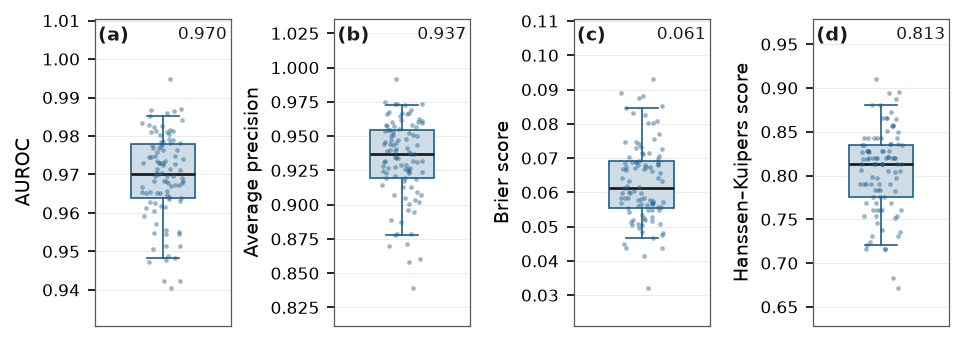

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(WIDTH, 2.35))
rng = np.random.default_rng(2026)
for i, (ax, (k, lab)) in enumerate(zip(axes, METRICS)):
    v = met[k].to_numpy()
    ax.boxplot(v, positions=[0], widths=0.52, whis=(5, 95), showfliers=False, patch_artist=True,
               boxprops=dict(facecolor=tint(GAM_COLOR, .22), edgecolor=GAM_COLOR, lw=.8),
               medianprops=dict(color=INK, lw=1.3),
               whiskerprops=dict(color=GAM_COLOR, lw=.8), capprops=dict(color=GAM_COLOR, lw=.8))
    ax.scatter(rng.uniform(-.17, .17, len(v)), v, s=5, color=GAM_COLOR, alpha=.45, lw=0, zorder=3)
    ax.set_xticks([])
    ax.set_xlim(-.55, .55)
    ax.set_ylabel(lab)
    pad = 0.18 * (v.max() - v.min() + 1e-9)
    ax.set_ylim(v.min() - pad, v.max() + 1.6 * pad)
    ax.grid(axis='y', alpha=.25, lw=.5)
    ax.set_axisbelow(True)
    frame(ax)
    letter(ax, 'abcd'[i])
    ax.text(0.97, 0.975, f'{np.median(v):.3f}', transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color=INK)
fig.tight_layout(w_pad=1.2)
savefig(fig, 'fig_gam_desempeno')
plt.show()

## 5. (b)–(c) Partial effects

Top: the two rainfall terms; bottom: ENSO phase, rainfall zone and slope unit type. Blue: the
final model with its 95 % confidence interval; grey: the 5th–95th percentile of the same term
over the Monte Carlo runs. All terms are centred on their mean over the observations (pyGAM
leaves the constant spread between the intercept and the terms), so zero marks the average
contribution of each term and only the shape and the differences between levels carry
meaning. The two rainfall panels share the vertical axis, and so do the three factor panels,
so the size of the effects can be compared.

Ticks under the rainfall curves: landslides (dark) and non-landslides of the final model's run
(grey). The grey band in (a) is the rainfall range excluded by the exposure filter.

guardada: 00Figuras/06Seccion/fig_gam_efectos_excl10d_libre.pdf


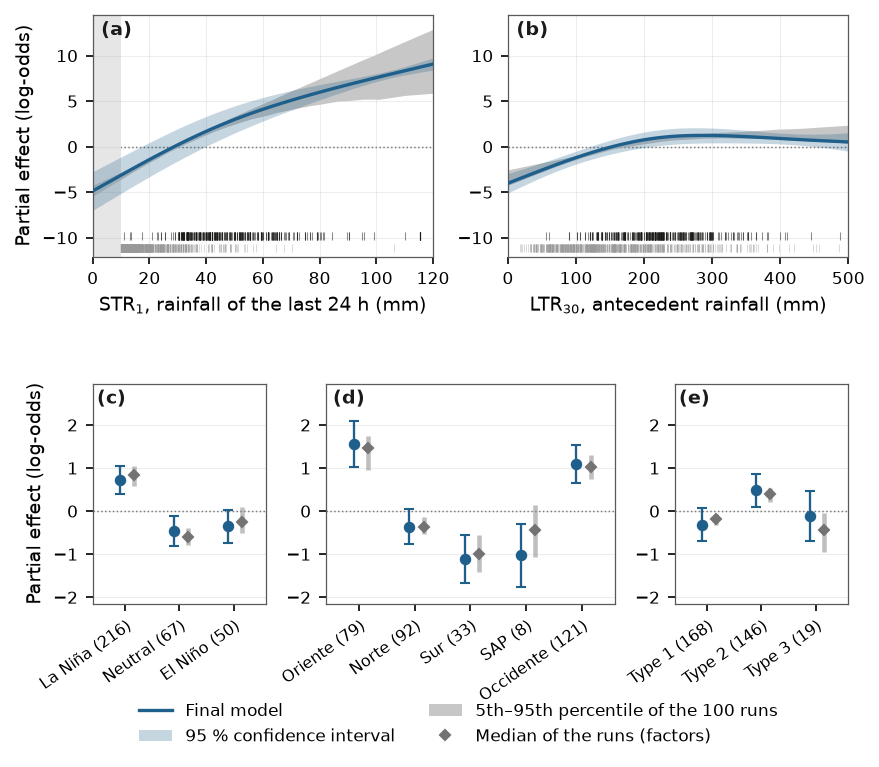

In [6]:
def curva(e, term, centro):
    g = e[e['term'] == term]
    x = g['x'].to_numpy(float)
    return x, g['effect'].to_numpy(float) - centro, g['lo'].to_numpy(float) - centro, g['hi'].to_numpy(float) - centro

def envolvente(term):
    m = eff[eff['term'] == term].pivot(index='x', columns='run_id', values='effect')
    cen = met.set_index('run_id')[f'centro_{term}'].reindex(m.columns).to_numpy()
    m = m - cen[None, :]
    return m.index.to_numpy(float), m.quantile(.05, axis=1).to_numpy(), m.quantile(.95, axis=1).to_numpy(), m

def factor_centrado(term, niveles):
    """Efecto por nivel centrado en la media ponderada por observaciones (final y corridas)."""
    fin = eff_final[eff_final['term'] == term].set_index('level').loc[niveles]
    w = star[term].astype(str).value_counts().reindex(niveles).fillna(0).to_numpy(float)
    c = np.average(fin['effect'], weights=w)
    y, lo, hi = fin['effect'] - c, fin['lo'] - c, fin['hi'] - c
    mc = eff[eff['term'] == term].pivot(index='run_id', columns='level', values='effect')[niveles]
    wr = lev[lev['variable'] == term].groupby(['run_id', 'level'])['n'].sum().unstack()[niveles].fillna(0)
    mc = mc.sub((mc * wr).sum(axis=1) / wr.sum(axis=1), axis=0)
    return y, lo, hi, mc

STR_MAX_EF = float(min(STR_TOP, np.ceil(np.nanpercentile(star['STR'], 99.5) / 10) * 10))
LTR_MAX_EF = float(min(LTR_TOP, np.ceil(np.nanpercentile(star['LTR'], 99.5) / 50) * 50))

fig = plt.figure(figsize=(WIDTH, 5.1))
gs = GridSpec(2, 1, figure=fig, height_ratios=[1.1, 1], hspace=0.55)
g_top = gs[0].subgridspec(1, 2, wspace=0.22)
g_bot = gs[1].subgridspec(1, 3, width_ratios=[len(ENSO_ORDER), len(ZONES), len(TYPES)], wspace=0.28)
ax_s, ax_l = fig.add_subplot(g_top[0]), fig.add_subplot(g_top[1])
ax_e, ax_z, ax_t = fig.add_subplot(g_bot[0]), fig.add_subplot(g_bot[1]), fig.add_subplot(g_bot[2])

# ---- rainfall terms
lims = []
for ax, term, xmax, xlab in [(ax_s, 'STR', STR_MAX_EF, 'STR$_1$, rainfall of the last 24 h (mm)'),
                             (ax_l, 'LTR', LTR_MAX_EF, 'LTR$_{30}$, antecedent rainfall (mm)')]:
    x, y, lo, hi = curva(eff_final, term, FIN[f'centro_{term}'])
    xe, elo, ehi, _ = envolvente(term)
    m, me = x <= xmax, xe <= xmax
    ax.fill_between(xe[me], elo[me], ehi[me], color=RUNS_COLOR, lw=0, zorder=1)
    ax.fill_between(x[m], lo[m], hi[m], color=GAM_COLOR, alpha=.25, lw=0, zorder=2)
    ax.plot(x[m], y[m], color=GAM_COLOR, lw=1.6, zorder=3)
    ax.axhline(0, color=MUTED, lw=.7, ls=':', zorder=0)
    ax.set_xlim(0, xmax)
    ax.set_xlabel(xlab)
    lims += [np.nanmin(np.r_[lo[m], elo[me]]), np.nanmax(np.r_[hi[m], ehi[me]])]
    # alfombra: deslizamientos arriba de la de no deslizamientos
    tr = ax.get_xaxis_transform()
    ax.scatter(star.loc[star.si_no == 0, term], np.full((star.si_no == 0).sum(), 0.035), marker='|',
               s=14, lw=.5, color='0.6', alpha=.35, transform=tr, zorder=4)
    ax.scatter(ev[term], np.full(len(ev), 0.085), marker='|', s=14, lw=.5, color=INK, alpha=.5,
               transform=tr, zorder=4)
ylo, yhi = min(lims), max(lims)
pad = 0.08 * (yhi - ylo)
for ax in (ax_s, ax_l):
    ax.set_ylim(ylo - 3.2 * pad, yhi + pad)       # espacio abajo para la alfombra
    ax.grid(alpha=.22, lw=.5)
    ax.set_axisbelow(True)
    frame(ax)
ax_s.axvspan(0, U1, color='0.90', lw=0, zorder=0)
ax_s.set_ylabel('Partial effect (log-odds)')
letter(ax_s, 'a')
letter(ax_l, 'b')

# ---- factors
fac_lims, fac_tab = [], []
for ax, term, niveles, lab, let in [(ax_e, 'ENSO', ENSO_ORDER, lambda e: ENSO_LABEL[e], 'c'),
                                    (ax_z, 'zona', ZONES, lambda z: ZONE_LABEL.get(z, z), 'd'),
                                    (ax_t, 'tipo_su', TYPES, TYPE_LABEL, 'e')]:
    y, lo, hi, mc = factor_centrado(term, niveles)
    pos = np.arange(len(niveles))
    mmed, mlo, mhi = mc.median(), mc.quantile(.05), mc.quantile(.95)
    ax.vlines(pos + .16, mlo, mhi, color='0.55', lw=2.2, alpha=.55, zorder=2)
    ax.plot(pos + .16, mmed, 'D', ms=3.4, color='0.45', zorder=3)
    ax.errorbar(pos - .10, y, yerr=[y - lo, hi - y], fmt='o', ms=4.5, color=GAM_COLOR,
                capsize=2.5, lw=1.1, zorder=4)
    n_si = [int((ev[term].astype(str) == l).sum()) for l in niveles]
    ax.set_xticks(pos)
    ax.set_xticklabels([f'{lab(l)} ({n})' for l, n in zip(niveles, n_si)], fontsize=7.5,
                       rotation=35, ha='right', rotation_mode='anchor')
    ax.set_xlim(-.6, len(niveles) - .4)
    ax.axhline(0, color=MUTED, lw=.7, ls=':', zorder=0)
    ax.grid(axis='y', alpha=.22, lw=.5)
    ax.set_axisbelow(True)
    frame(ax)
    letter(ax, let)
    fac_lims += [np.nanmin(np.r_[lo, mlo]), np.nanmax(np.r_[hi, mhi])]
    for l, a, b, c, n in zip(niveles, y, lo, hi, n_si):
        fac_tab.append({'variable': term, 'level': l, 'label': lab(l), 'landslides': n,
                        'effect': a, 'ci_lo': b, 'ci_hi': c,
                        'runs_median': mmed[l], 'runs_p05': mlo[l], 'runs_p95': mhi[l]})
flo, fhi = min(fac_lims), max(fac_lims)
for ax in (ax_e, ax_z, ax_t):
    ax.set_ylim(flo - .1 * (fhi - flo), fhi + .22 * (fhi - flo))
ax_e.set_ylabel('Partial effect (log-odds)')

handles = [Line2D([], [], color=GAM_COLOR, lw=1.6, label='Final model'),
           Patch(facecolor=GAM_COLOR, alpha=.25, label='95 % confidence interval'),
           Patch(facecolor=RUNS_COLOR, label=f'5th–95th percentile of the {N_RUNS} runs'),
           Line2D([], [], marker='D', color='0.45', ls='none', ms=3.4,
                  label='Median of the runs (factors)')]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2,
           frameon=False, fontsize=8)
savefig(fig, 'fig_gam_efectos')
plt.show()

fac_tab = pd.DataFrame(fac_tab)
fac_tab.to_csv(TAB_DIR / f'tabla_res_gam_factores{SUF}.csv', index=False)

In [7]:
# ---------------------------------------------------------------- numbers for (b)
def describir(term, marcas):
    """Forma de la curva final (centrada) dentro del rango observado."""
    x, y, lo, hi = curva(eff_final, term, FIN[f'centro_{term}'])
    obs = pd.concat([star[term], ev[term]])
    a, b = np.nanpercentile(obs, [1, 99])
    m = (x >= a) & (x <= b)
    xm, ym = x[m], y[m]
    d = np.gradient(ym, xm)
    k = int(np.argmax(d))
    plano = np.nonzero((np.arange(len(d)) > k) & (d < 0.25 * d[k]))[0]
    baja = xm[d < -1e-4]
    _, _, _, mc = envolvente(term)
    mc = mc.loc[(mc.index >= a) & (mc.index <= b)]
    mono_runs = float((np.diff(mc.to_numpy(), axis=0) >= -1e-6).all(axis=0).mean())
    print(f'--- {term}: rango observado (P1-P99) {a:.0f}-{b:.0f} mm')
    print(f'  cambio en ese rango: {ym[-1] - ym[0]:+.2f} log-odds (odds x {np.exp(ym[-1] - ym[0]):.1f})')
    print(f'  pendiente máxima en {xm[k]:.0f} mm ({d[k]:.3f} log-odds/mm)')
    print('  se aplana (pendiente < 25 % de la máxima) desde: '
          + (f'{xm[plano[0]]:.0f} mm' if len(plano) else 'no se aplana en el rango'))
    print('  tramos decrecientes: ' + (f'{baja.min():.0f}-{baja.max():.0f} mm' if len(baja) else 'ninguno')
          + f' | corridas monótonas crecientes: {100 * mono_runs:.0f} %')
    for v in marcas:
        if a <= v <= b:
            i = int(np.argmin(np.abs(x - v)))
            print(f'  s({v:g} mm) = {y[i]:+.2f} [{lo[i]:+.2f}, {hi[i]:+.2f}]')

describir('STR', [10, 20, 30, 40, 60, 80, 100])
describir('LTR', [50, 100, 150, 200, 300, 400, 500])

# ---------------------------------------------------------------- numbers for (c)
print('\n--- factores (centrados; IC 95 % del modelo final; corridas: mediana [P5-P95])')
for v, g in fac_tab.groupby('variable', sort=False):
    print(g[['label', 'landslides', 'effect', 'ci_lo', 'ci_hi', 'runs_median', 'runs_p05',
             'runs_p95']].round(2).to_string(index=False))
    dmax = g['effect'].max() - g['effect'].min()
    i, j = g['effect'].idxmax(), g['effect'].idxmin()
    print(f"  {g.loc[i, 'label']} frente a {g.loc[j, 'label']}: {dmax:.2f} log-odds "
          f"(odds x {np.exp(dmax):.2f})\n")

--- STR: rango observado (P1-P99) 10-115 mm
  cambio en ese rango: +11.66 log-odds (odds x 116085.2)
  pendiente máxima en 11 mm (0.174 log-odds/mm)
  se aplana (pendiente < 25 % de la máxima) desde: no se aplana en el rango
  tramos decrecientes: ninguno | corridas monótonas crecientes: 98 %
  s(20 mm) = -1.42 [-3.30, +0.46]
  s(30 mm) = +0.20 [-1.56, +1.97]
  s(40 mm) = +1.68 [+0.04, +3.33]
  s(60 mm) = +4.11 [+2.81, +5.40]
  s(80 mm) = +5.98 [+5.15, +6.82]
  s(100 mm) = +7.59 [+7.15, +8.02]
--- LTR: rango observado (P1-P99) 38-452 mm
  cambio en ese rango: +3.55 log-odds (odds x 34.7)
  pendiente máxima en 40 mm (0.029 log-odds/mm)
  se aplana (pendiente < 25 % de la máxima) desde: 235 mm
  tramos decrecientes: 290-450 mm | corridas monótonas crecientes: 47 %
  s(50 mm) = -2.56 [-3.35, -1.77]
  s(100 mm) = -1.20 [-1.91, -0.49]
  s(150 mm) = -0.06 [-0.83, +0.71]
  s(200 mm) = +0.76 [-0.09, +1.61]
  s(300 mm) = +1.23 [+0.42, +2.05]
  s(400 mm) = +0.90 [+0.30, +1.50]

--- factores (cen

## 6. (d) Probability cut-offs and the four rainfall classes

`tabla_res_gam_cortes`: each cut-off with the true and false positive rates it reaches on the
test part, over the runs. `tabla_res_gam_clases`: how the landslides and the non-landslides of
the test part fall in the four classes, and the ratio between the two shares (the rainfall
counterpart of the density ratio of the susceptibility classes, `tab:st-classes`).

In [8]:
filas = []
for key in ['P_TPR95', 'P_TPR85', 'P_TPR70', 'P_OPT']:
    t = thr[thr['thr_level'] == key]
    filas.append({'cutoff': key, 'opens': {v: k for k, v in LEVEL_KEY.items()}.get(key, 'reference'),
                  'p_median': t['threshold'].median(), 'p_p05': q05(t['threshold']),
                  'p_p95': q95(t['threshold']), 'tpr_median': t['tpr'].median(),
                  'fpr_median': t['fpr'].median(), 'fpr_p05': q05(t['fpr']), 'fpr_p95': q95(t['fpr']),
                  'hk_median': (t['tpr'] - t['fpr']).median()})
tab_cortes = pd.DataFrame(filas)
tab_cortes.to_csv(TAB_DIR / f'tabla_res_gam_cortes{SUF}.csv', index=False)
print(tab_cortes.round(3).to_string(index=False))

# --- the four classes: share of each group, per run -------------------------------------
w = thr[thr['thr_level'] != 'P_OPT'].pivot(index='run_id', columns='thr_level', values=['tpr', 'fpr'])
def reparto(col):
    a = w[col]
    return pd.DataFrame({'Low': 1 - a['P_TPR95'], 'Moderate': a['P_TPR95'] - a['P_TPR85'],
                         'High': a['P_TPR85'] - a['P_TPR70'], 'Very high': a['P_TPR70']})
si, no = reparto('tpr'), reparto('fpr')
razon = si / no.replace(0, np.nan)
lims_p = [0] + [PSTAR[c] for c in CLASSES[1:]] + [1]
tab_clases = pd.DataFrame({
    'class': CLASSES,
    'p_from': lims_p[:-1], 'p_to': lims_p[1:],
    'landslides_pct': 100 * si.median().to_numpy(),
    'non_landslides_pct': 100 * no.median().to_numpy(),
    'non_landslides_p05': 100 * no.quantile(.05).to_numpy(),
    'non_landslides_p95': 100 * no.quantile(.95).to_numpy(),
    'ratio_median': razon.median().to_numpy(),
    'ratio_p05': razon.quantile(.05).to_numpy(), 'ratio_p95': razon.quantile(.95).to_numpy()})
tab_clases.to_csv(TAB_DIR / f'tabla_res_gam_clases{SUF}.csv', index=False)
print('\n', tab_clases.round(3).to_string(index=False))

# --- LaTeX: cut-offs ---------------------------------------------------------------------
NOM = {'P_TPR95': r'$P^{*}_{95}$', 'P_TPR85': r'$P^{*}_{85}$', 'P_TPR70': r'$P^{*}_{70}$',
       'P_OPT': 'Youden (reference)'}
print('\n% ---- LaTeX: tab:res-gam-cutoffs')
print(r'\begin{table}[ht]' '\n' r'\centering' '\n' r'\footnotesize')
print(r'\begin{tabular}{llcccc}' '\n' r'\hline')
print(r'\textbf{Cut-off} & \textbf{Opens class} & \textbf{$p^{*}$} & \textbf{TPR} & '
      r'\textbf{FPR} & \textbf{HK} \\' '\n' r'\hline')
for _, r in tab_cortes.iterrows():
    print(f"{NOM[r['cutoff']]} & {r['opens'].capitalize() if r['opens'] != 'reference' else '--'} & "
          f"{r['p_median']:.3f} ({r['p_p05']:.3f}--{r['p_p95']:.3f}) & {r['tpr_median']:.2f} & "
          f"{r['fpr_median']:.2f} ({r['fpr_p05']:.2f}--{r['fpr_p95']:.2f}) & {r['hk_median']:.2f} \\\\")
print(r'\hline' '\n' r'\end{tabular}')
print(r'\caption{Probability cut-offs of the rainfall model and the rates they reach on the test '
      r'part: median over the ' + str(N_RUNS) + r' Monte Carlo runs, with the 5th--95th percentile '
      r'in brackets. TPR, true positive rate; FPR, false positive rate; HK, Hanssen--Kuipers score '
      r'(TPR $-$ FPR). The Youden cut-off is given only as a reference.}')
print(r'\label{tab:res-gam-cutoffs}' '\n' r'\end{table}')

# --- LaTeX: classes ----------------------------------------------------------------------
print('\n% ---- LaTeX: tab:res-gam-classes')
print(r'\begin{table}[ht]' '\n' r'\centering' '\n' r'\footnotesize')
print(r'\begin{tabular}{lcccc}' '\n' r'\hline')
print(r'\textbf{Rainfall class} & \textbf{Probability} & \textbf{Landslides (\%)} & '
      r'\textbf{Non-landslides (\%)} & \textbf{Ratio} \\' '\n' r'\hline')
for _, r in tab_clases.iloc[::-1].iterrows():
    rango = (f"$p \\ge {r['p_from']:.3f}$" if r['class'] == 'Very high' else
             f"$p < {r['p_to']:.3f}$" if r['class'] == 'Low' else
             f"{r['p_from']:.3f}--{r['p_to']:.3f}")
    print(f"{r['class']} & {rango} & {r['landslides_pct']:.1f} & {r['non_landslides_pct']:.1f} "
          f"({r['non_landslides_p05']:.1f}--{r['non_landslides_p95']:.1f}) & "
          f"{r['ratio_median']:.2f} \\\\")
print(r'\hline' '\n' r'\end{tabular}')
print(r'\caption{The four rainfall classes. \emph{Landslides} and \emph{non-landslides} give the '
      r'share of each group of the test part that falls in the class (median over the runs; '
      r'5th--95th percentile in brackets), and the ratio divides the first share by the second.}')
print(r'\label{tab:res-gam-classes}' '\n' r'\end{table}')

 cutoff     opens  p_median  p_p05  p_p95  tpr_median  fpr_median  fpr_p05  fpr_p95  hk_median
P_TPR95  Moderate     0.274  0.086  0.464       0.955       0.105    0.052    0.211      0.850
P_TPR85      High     0.514  0.380  0.653       0.866       0.053    0.023    0.091      0.813
P_TPR70 Very high     0.731  0.563  0.840       0.746       0.023    0.007    0.061      0.722
  P_OPT reference     0.345  0.208  0.480       0.955       0.083    0.044    0.134      0.865

     class  p_from  p_to  landslides_pct  non_landslides_pct  non_landslides_p05  non_landslides_p95  ratio_median  ratio_p05  ratio_p95
      Low   0.000 0.274           4.478              89.474              78.910              94.776         0.049      0.032      0.055
 Moderate   0.274 0.514           9.091               5.263               1.493              15.678         1.654      0.658      5.955
     High   0.514 0.731          11.940               2.256               0.746               4.547         4.632  

guardada: 00Figuras/06Seccion/fig_gam_roc_calibracion_excl10d_libre.pdf
         p    obs     lo     hi  runs
bin                                  
0    0.020  0.010  0.000  0.035   100
1    0.143  0.077  0.000  0.273   100
2    0.247  0.200  0.000  0.500    77
3    0.346  0.429  0.093  0.609    54
4    0.452  0.600  0.165  0.835    60
5    0.549  0.667  0.400  1.000    69
6    0.647  0.714  0.493  1.000    59
7    0.754  0.800  0.475  1.000    74
8    0.857  0.905  0.749  1.000   100
9    0.971  0.953  0.872  1.000   100


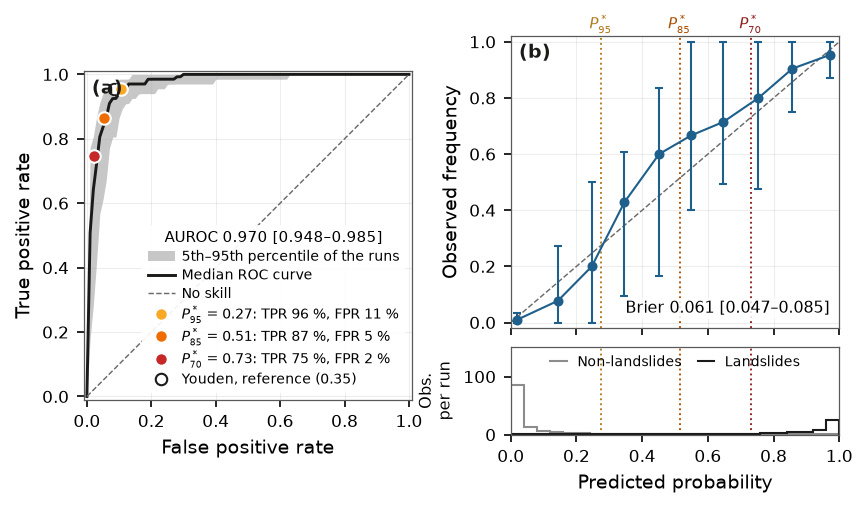

In [9]:
# ---------------------------------------------------------------- ROC + reliability
curva_roc = (roc.groupby('fpr')['tpr'].agg(med='median', lo=q05, hi=q95).reset_index())

fig = plt.figure(figsize=(WIDTH, 3.45))
gs = GridSpec(2, 2, figure=fig, height_ratios=[4, 1.2], hspace=0.10, wspace=0.30)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)

# (a) ROC; los números de cada corte van en la leyenda, sin flechas que se crucen
ax1.fill_between(curva_roc['fpr'], curva_roc['lo'], curva_roc['hi'], color=RUNS_COLOR, lw=0)
ax1.plot(curva_roc['fpr'], curva_roc['med'], color=INK, lw=1.4)
ax1.plot([0, 1], [0, 1], color=MUTED, lw=.7, ls='--')
handles = [Patch(facecolor=RUNS_COLOR, label='5th–95th percentile of the runs'),
           Line2D([], [], color=INK, lw=1.4, label='Median ROC curve'),
           Line2D([], [], color=MUTED, lw=.7, ls='--', label='No skill')]
for c, key in LEVEL_KEY.items():
    r = cortes.loc[key]
    ax1.plot(r['fpr'], r['tpr'], 'o', ms=6, mfc=BASE[c], mec='white', mew=1, zorder=6)
    handles.append(Line2D([], [], marker='o', ls='none', ms=6, mfc=BASE[c], mec='white',
                          label=f"{KEY_LABEL[key]} = {r['threshold']:.2f}: "
                                f"TPR {100 * r['tpr']:.0f} %, FPR {100 * r['fpr']:.0f} %"))
ro = cortes.loc['P_OPT']
ax1.plot(ro['fpr'], ro['tpr'], 'o', ms=5.5, mfc='white', mec=INK, mew=.9, zorder=5)
handles.append(Line2D([], [], marker='o', ls='none', ms=5.5, mfc='white', mec=INK,
                      label=f"Youden, reference ({ro['threshold']:.2f})"))
ax1.legend(handles=handles, loc='lower right', fontsize=6.5, frameon=True, framealpha=.92,
           edgecolor='none', title=f"AUROC {med_rng(met['auc'])}", title_fontsize=7,
           borderpad=.45, handletextpad=.5, labelspacing=.32)
ax1.set_xlim(-0.01, 1.01)
ax1.set_ylim(-0.01, 1.01)
ax1.set_aspect('equal')
ax1.set_xlabel('False positive rate')
ax1.set_ylabel('True positive rate')
ax1.grid(alpha=.22, lw=.5)
frame(ax1)
letter(ax1, 'a')

# (b) reliability: frecuencia observada por clase de probabilidad, corrida a corrida
bins = np.linspace(0, 1, 11)
filas = []
for r, g in pred.groupby('run_id'):
    b = np.clip(np.digitize(g['p'], bins) - 1, 0, 9)
    for k in range(10):
        m = b == k
        if m.sum() >= 5:
            filas.append({'run_id': r, 'bin': k, 'p': g['p'][m].mean(), 'obs': g['y'][m].mean(),
                          'n': int(m.sum())})
rel = (pd.DataFrame(filas).groupby('bin')
       .agg(p=('p', 'median'), obs=('obs', 'median'), lo=('obs', q05), hi=('obs', q95),
            runs=('run_id', 'nunique')))
rel = rel[rel['runs'] >= 0.5 * N_RUNS]          # clases presentes en al menos la mitad de las corridas
ax2.plot([0, 1], [0, 1], color=MUTED, lw=.7, ls='--')
ax2.errorbar(rel['p'], rel['obs'], yerr=[rel['obs'] - rel['lo'], rel['hi'] - rel['obs']],
             fmt='o-', ms=3.8, lw=1, capsize=2, color=GAM_COLOR, zorder=4)
for c in CLASSES[1:]:
    for ax in (ax2, ax3):
        ax.axvline(PSTAR[c], color=LINE[c], lw=.9, ls=':', zorder=1)
    ax2.text(PSTAR[c], 1.01, KEY_LABEL[LEVEL_KEY[c]], transform=ax2.get_xaxis_transform(),
             ha='center', va='bottom', fontsize=7, color=LINE[c])
ax2.set_ylim(-0.02, 1.02)
ax2.set_ylabel('Observed frequency')
ax2.text(0.97, 0.04, f"Brier {med_rng(met['brier'])}", transform=ax2.transAxes, ha='right',
         va='bottom', fontsize=7.5, zorder=6,
         bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=.85))
ax2.grid(alpha=.22, lw=.5)
plt.setp(ax2.get_xticklabels(), visible=False)
frame(ax2)
letter(ax2, 'b')

# histograma de las probabilidades del test (promedio por corrida)
hb = np.linspace(0, 1, 26)
hmax = 0
for y_, col, lab in [(0, '0.55', 'Non-landslides'), (1, INK, 'Landslides')]:
    h, _ = np.histogram(pred.loc[pred['y'] == y_, 'p'], bins=hb)
    ax3.stairs(h / N_RUNS, hb, color=col, lw=1, label=lab)
    hmax = max(hmax, h.max() / N_RUNS)
ax3.set_ylim(0, 1.75 * hmax)                      # espacio arriba para la leyenda
ax3.legend(loc='upper center', ncol=2, fontsize=6.5, frameon=False, handlelength=1.2,
           borderaxespad=0.2, columnspacing=1.2)
ax3.set_xlim(0, 1)
ax3.set_xlabel('Predicted probability')
ax3.set_ylabel('Obs.\nper run', fontsize=7.5)
frame(ax3)
savefig(fig, 'fig_gam_roc_calibracion')
plt.show()
print(rel.round(3).to_string())

## 7. (e) Rainfall thresholds on the STR–LTR plane

One panel per rainfall zone (rows) and ENSO phase (columns), all with the same axes. Colours:
the four rainfall classes of the final model, separated by the three cut-offs (median over the
runs); each boundary reads as a classical rainfall threshold. The hatched corner is outside the
sampled conditions (R1 ≤ 10 mm or R30 ≤ 50 mm), where the model is not defined. Points:
landslides of that zone and phase (all slope unit types) and, in grey, the non-landslides of the
final model's run.

The slope unit type is fixed (`TYPE_FIX`, by default the most frequent among the landslides):
the model is additive, so another type moves every boundary in the same direction, by the
amount shown in panel (e) of the partial effects.

> **Cómo leer las columnas de ENSO según el diseño.**
> - Con la regla año-mes (`excl0d_anomes`), la fase ENSO queda igual en las dos clases por
>   construcción y las tres columnas saldrán casi iguales.
> - Sin ella (`excl10d_libre`), las columnas pueden diferir, pero revisa antes el desbalance
>   temporal de la sección 3: si las ausencias vienen de otros años, una parte de la diferencia
>   entre fases es de época (más reportes desde 2021, en plena La Niña) y no de ENSO.
>
> La celda imprime cuánto se mueve una frontera entre fases; si son pocos milímetros, usa
> `ENSO_COLS = ['Neutro']` para la versión compacta (una fase, cinco zonas en una rejilla 2 × 3).

Tipo fijo: 1 | ejes: LTR 0-500 mm, STR 0-120 mm
Desplazamiento máximo de una frontera (STR, mm, LTR = 220 mm): entre fases ENSO 9.9 | entre zonas 20.8
guardada: 00Figuras/06Seccion/fig_gam_isolineas_excl10d_libre.pdf


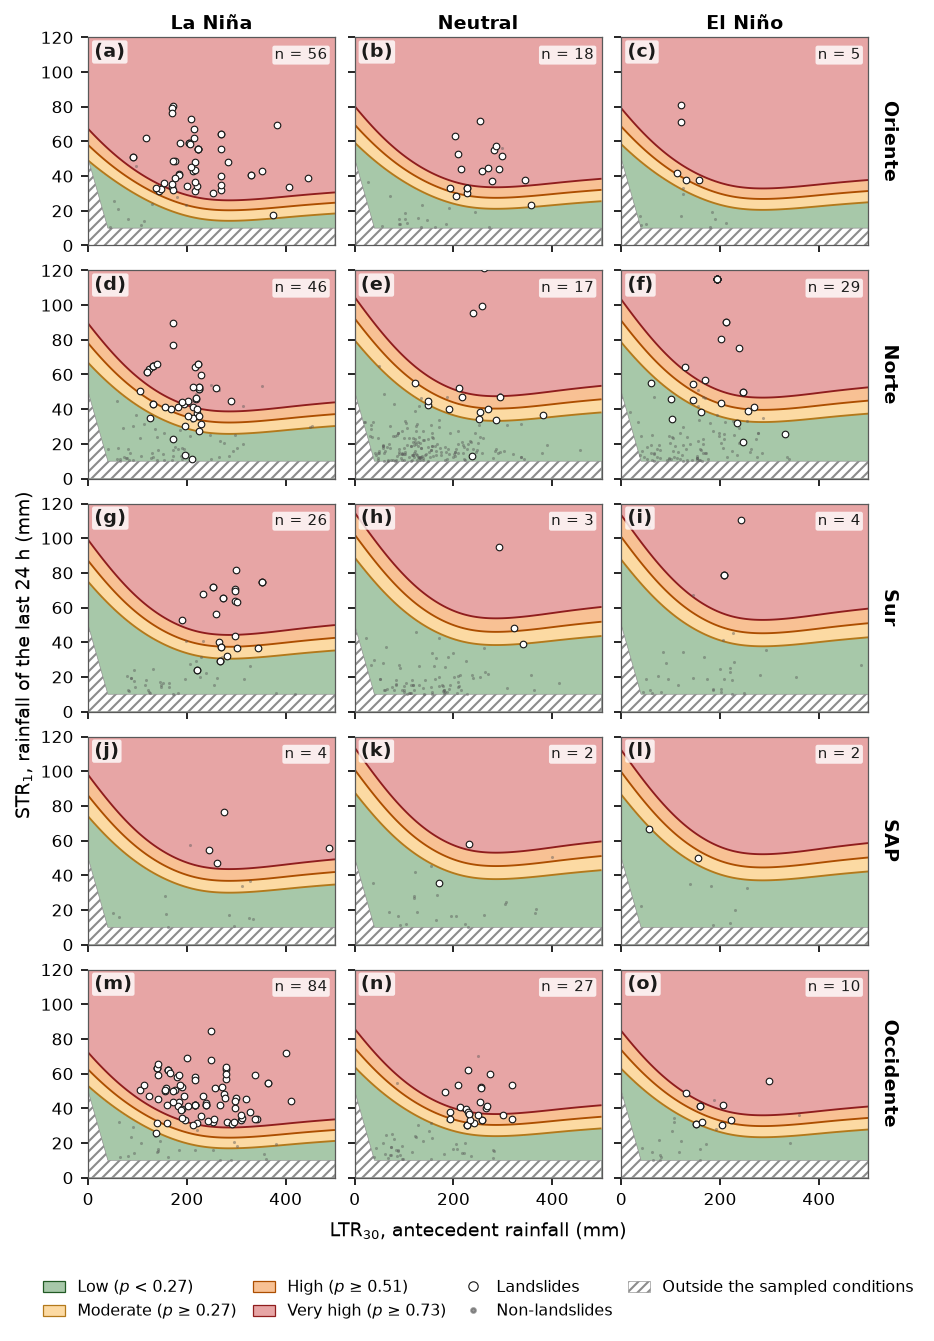

In [10]:
TYPE_FIX = ev['tipo_su'].astype(str).mode().iloc[0]
ENSO_COLS = ENSO_ORDER                   # ['Neutro'] -> versión compacta (ver nota)
STR_MAX = float(min(STR_TOP, np.ceil(np.nanpercentile(star['STR'], 99.5) / 10) * 10))
LTR_MAX = float(min(LTR_TOP, np.ceil(np.nanpercentile(star['LTR'], 99.5) / 50) * 50))
SHOW_ABSENCES = True
print(f'Tipo fijo: {TYPE_FIX} | ejes: LTR 0-{LTR_MAX:.0f} mm, STR 0-{STR_MAX:.0f} mm')

# ¿cuánto se mueve una frontera entre fases ENSO? (LTR mediano de los deslizamientos)
ltr50 = float(np.nanmedian(ev['LTR']))

def desplazamiento(grupos):
    """Mayor diferencia de STR entre los miembros de cada grupo, y casos sin cruce."""
    rangos, sin_cruce = [], 0
    for vals in grupos:
        v = np.array(vals, float)
        sin_cruce += int((~np.isfinite(v)).sum())
        v = v[np.isfinite(v)]
        if len(v) > 1:
            rangos.append(np.ptp(v))
    return (max(rangos) if rangos else np.nan), sin_cruce

mov, nc = desplazamiento([[str_needed(COMP_FINAL, e, z, TYPE_FIX, ltr50, PSTAR[c]) for e in ENSO_ORDER]
                          for z in ZONES for c in CLASSES[1:]])
mov_z, nc_z = desplazamiento([[str_needed(COMP_FINAL, 'Neutro', z, TYPE_FIX, ltr50, PSTAR[c]) for z in ZONES]
                              for c in CLASSES[1:]])
print(f'Desplazamiento máximo de una frontera (STR, mm, LTR = {ltr50:.0f} mm): entre fases ENSO '
      f'{mov:.1f} | entre zonas {mov_z:.1f}')
if nc or nc_z:
    print(f'  ({nc + nc_z} combinaciones no alcanzan alguna clase dentro de 150 mm)')

xs = COMP_FINAL['LTR'][0]
xs = xs[xs <= LTR_MAX]
ys = COMP_FINAL['STR'][0]
ys = ys[ys <= STR_MAX]

def superficie(c, enso, zona, tipo):
    s1 = np.interp(ys, *c['STR'])
    s2 = np.interp(xs, *c['LTR'])
    return expit(c['b0'] + s1[:, None] + s2[None, :] + c['ENSO'][enso] + c['zona'][zona]
                 + c['tipo_su'][tipo])

def etiqueta_clase(c):
    if c == 'Low':
        return f"Low ($p$ < {PSTAR['Moderate']:.2f})"
    return f"{c} ($p$ ≥ {PSTAR[c]:.2f})"

# esquina fuera de las condiciones muestreadas: STR <= U1 o R30 <= U30.
# Con LTR = R30 - R1, R30 = STR + LTR y la frontera es exacta; con R31 - R1 es aproximada.
NO_MUESTREO = [(0, 0), (LTR_MAX, 0), (LTR_MAX, U1), (U30 - U1, U1), (0, U30)]

matriz = len(ENSO_COLS) > 1
if matriz:
    nrow, ncol = len(ZONES), len(ENSO_COLS)
    celdas = [(i, j, z, e) for i, z in enumerate(ZONES) for j, e in enumerate(ENSO_COLS)]
    alto = 1.62 * nrow + 0.95
else:
    ncol = 3
    nrow = int(np.ceil((len(ZONES) + 1) / ncol))      # +1: hueco para la leyenda
    celdas = [(k // ncol, k % ncol, z, ENSO_COLS[0]) for k, z in enumerate(ZONES)]
    alto = 2.05 * nrow + 0.55
fig, axes = plt.subplots(nrow, ncol, figsize=(WIDTH, alto), sharex=True, sharey=True, squeeze=False)
niveles_p = [0.0] + [PSTAR[c] for c in CLASSES[1:]] + [1.0]
letras = 'abcdefghijklmnopqrstuvwxyz'
usados = set()
for k, (i, j, z, e) in enumerate(celdas):
    ax = axes[i][j]
    usados.add((i, j))
    Pz = superficie(COMP_FINAL, e, z, TYPE_FIX)
    ax.contourf(xs, ys, Pz, levels=niveles_p, colors=[FILL[c] for c in CLASSES], zorder=0)
    ax.contour(xs, ys, Pz, levels=niveles_p[1:-1], colors=[LINE[c] for c in CLASSES[1:]],
               linewidths=0.9, zorder=1)
    ax.add_patch(MplPolygon(NO_MUESTREO, closed=True, facecolor='white', edgecolor='0.55',
                            hatch='/////', lw=0.3, zorder=2))
    # en la versión compacta se dibujan las observaciones de todas las fases
    fase = (star['ENSO'] == e) if matriz else True
    if SHOW_ABSENCES:
        a = star[(star['si_no'] == 0) & (star['zona'] == z) & fase]
        ax.scatter(a['LTR'], a['STR'], s=2.2, color='0.35', alpha=.45, lw=0, zorder=3)
    sub = ev[(ev['zona'] == z) & ((ev['ENSO'] == e) if matriz else True)]
    ax.scatter(sub['LTR'], sub['STR'], s=10, facecolor='white', edgecolor=INK, lw=.55, zorder=4)
    ax.text(0.97, 0.95, f'n = {len(sub)}', transform=ax.transAxes, ha='right', va='top',
            fontsize=7, color=INK, zorder=5,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=.8))
    ax.set_xlim(0, LTR_MAX)
    ax.set_ylim(0, STR_MAX)
    paso = 200 if (matriz or LTR_MAX > 600) else 100      # sin marca en el borde: no se pegan
    ax.set_xticks(np.arange(0, LTR_MAX - 1e-9, paso))
    frame(ax)
    if matriz:
        letter(ax, letras[k], box=True)
        if i == 0:
            ax.set_title(ENSO_LABEL[e], fontsize=9, fontweight='bold', pad=4)
        if j == ncol - 1:
            ax.text(1.05, 0.5, ZONE_LABEL.get(z, z), transform=ax.transAxes, rotation=-90,
                    ha='left', va='center', fontsize=9, fontweight='bold')
    else:
        ax.text(0.025, 0.975, f'({letras[k]}) {ZONE_LABEL.get(z, z)}', transform=ax.transAxes,
                ha='left', va='top', fontsize=9, fontweight='bold', color=INK, zorder=10,
                bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=.8))

handles = [Patch(facecolor=FILL[c], edgecolor=LINE[c], lw=.6, label=etiqueta_clase(c))
           for c in CLASSES]
handles += [Line2D([], [], marker='o', mfc='white', mec=INK, mew=.55, ls='none', ms=4.5,
                   label='Landslides'),
            Line2D([], [], marker='o', color='0.35', alpha=.6, ls='none', ms=2.2,
                   label='Non-landslides'),
            Patch(facecolor='white', edgecolor='0.55', hatch='/////', lw=.3,
                  label='Outside the sampled conditions')]
libres = [(i, j) for i in range(nrow) for j in range(ncol) if (i, j) not in usados]
for (i, j) in libres:
    axes[i][j].axis('off')
    if i > 0:                                  # recupera las marcas del eje x del panel de arriba
        axes[i - 1][j].tick_params(labelbottom=True)

if matriz:
    fig.subplots_adjust(left=0.10, right=0.90, top=0.955, bottom=0.115, hspace=0.12, wspace=0.08)
    fig.supxlabel('LTR$_{30}$, antecedent rainfall (mm)', fontsize=9, y=0.068)
    fig.supylabel('STR$_1$, rainfall of the last 24 h (mm)', fontsize=9, x=0.025)
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=4,
               frameon=False, fontsize=7.5, handlelength=1.4, columnspacing=1.0)
else:
    fig.subplots_adjust(left=0.10, right=0.98, top=0.97, bottom=0.12, hspace=0.12, wspace=0.08)
    fig.supxlabel('LTR$_{30}$, antecedent rainfall (mm)', fontsize=9, y=0.035)
    fig.supylabel('STR$_1$, rainfall of the last 24 h (mm)', fontsize=9, x=0.025)
    i, j = libres[0]
    axes[i][j].legend(handles=handles, loc='center', frameon=False, fontsize=7.5,
                      title=f'Surface: {ENSO_LABEL[ENSO_COLS[0]]} phase, {TYPE_LABEL(TYPE_FIX).lower()}\n'
                            'Points: all phases and types', title_fontsize=7.5)
savefig(fig, 'fig_gam_isolineas')
plt.show()

### Rainfall needed to reach each class

The last-day rainfall (STR) at which each boundary is crossed, for the average antecedent
rainfall of the landslides (median LTR) and, in the CSV, also for a dry and a wet month (25th
and 75th percentiles). First value: final model with the median cut-offs, i.e. the boundary
drawn in the figure; brackets: 5th–95th percentile over the runs, each run with its own model
and cut-offs. `<10` means the boundary lies inside the unsampled band (the class is reached with
any rain above the exposure filter); `>150`, that it is not reached within 150 mm.

In [11]:
LTR_REF = dict(zip(['dry (P25)', 'average (P50)', 'wet (P75)'],
                   np.nanpercentile(ev['LTR'], [25, 50, 75])))
print('LTR de referencia (mm):', {k: round(v) for k, v in LTR_REF.items()})

cut_run = thr.pivot(index='run_id', columns='thr_level', values='threshold')

def tabla_mm(combos):
    filas = []
    for (z, e, t) in combos:
        for lab_l, ltr in LTR_REF.items():
            fila = {'zona': z, 'zone': ZONE_LABEL.get(z, z), 'ENSO': ENSO_LABEL[e], 'tipo_su': t,
                    'antecedent': lab_l, 'LTR_mm': ltr}
            for c, key in LEVEL_KEY.items():
                fila[f'{c}_final'] = str_needed(COMP_FINAL, e, z, t, ltr, PSTAR[c])
                runs = [str_needed(COMP_RUN[r], e, z, t, ltr, cut_run.loc[r, key]) for r in COMP_RUN]
                runs = np.array(runs, float)
                fila[f'{c}_p05'] = float(np.percentile(runs, 5))
                fila[f'{c}_p95'] = float(np.percentile(runs, 95))
            filas.append(fila)
    return pd.DataFrame(filas)

mm = tabla_mm([(z, e, TYPE_FIX) for z in ZONES for e in ENSO_ORDER])
mm.to_csv(TAB_DIR / f'tabla_res_gam_umbrales_mm{SUF}.csv', index=False)
mm_tipo = tabla_mm([(ev['zona'].mode().iloc[0], 'Neutro', t) for t in TYPES])
mm_tipo.to_csv(TAB_DIR / f'tabla_res_gam_umbrales_mm_tipo{SUF}.csv', index=False)

def fmt_mm(v):
    if np.isinf(v):
        return '>150'
    if v < U1:
        return f'<{U1:g}'
    return f'{v:.0f}'

def celda(r, c):
    return f"{fmt_mm(r[f'{c}_final'])} ({fmt_mm(r[f'{c}_p05'])}--{fmt_mm(r[f'{c}_p95'])})"

vista = mm[mm['antecedent'] == 'average (P50)']
print('\n', vista[['zone', 'ENSO'] + [f'{c}_final' for c in LEVEL_KEY]].round(0).to_string(index=False))
print('\nPor tipo (zona más frecuente, fase neutra, LTR mediano):')
print(mm_tipo[mm_tipo['antecedent'] == 'average (P50)'][['tipo_su'] + [f'{c}_final' for c in LEVEL_KEY]]
      .round(0).to_string(index=False))

print('\n% ---- LaTeX: tab:res-gam-mm')
print(r'\begin{table}[ht]' '\n' r'\centering' '\n' r'\footnotesize')
print(r'\begin{tabular}{llccc}' '\n' r'\hline')
print(r'\textbf{Zone} & \textbf{ENSO phase} & \textbf{Moderate} & \textbf{High} & '
      r'\textbf{Very high} \\' '\n' r'\hline')
prev = None
for _, r in vista.iterrows():
    zl = r['zone'] if r['zone'] != prev else ''
    prev = r['zone']
    print(f"{zl} & {r['ENSO']} & " + ' & '.join(celda(r, c) for c in LEVEL_KEY) + r' \\')
print(r'\hline' '\n' r'\end{tabular}')
print(r'\caption{Rainfall of the last 24~h (STR$_1$, mm) needed to reach each rainfall class, '
      rf"for an antecedent rainfall of {LTR_REF['average (P50)']:.0f}~mm (the median of the "
      rf"landslide observations) and slope units of type {TYPE_FIX}. First value: final model and "
      r'median cut-offs, as drawn in Fig.~\ref{fig:res-gam-isolines}; in brackets, the '
      r'5th--95th percentile over the Monte Carlo runs. $<10$: the class is reached with any '
      r'rainfall above the exposure filter.}')
print(r'\label{tab:res-gam-mm}' '\n' r'\end{table}')

LTR de referencia (mm): {'dry (P25)': 182, 'average (P50)': 220, 'wet (P75)': 269}

      zone    ENSO  Moderate_final  High_final  Very high_final
  Oriente La Niña            16.0        22.0             28.0
  Oriente Neutral            23.0        29.0             35.0
  Oriente El Niño            22.0        29.0             35.0
    Norte La Niña            27.0        34.0             41.0
    Norte Neutral            35.0        42.0             50.0
    Norte El Niño            34.0        42.0             49.0
      Sur La Niña            32.0        39.0             46.0
      Sur Neutral            40.0        48.0             56.0
      Sur El Niño            40.0        47.0             55.0
      SAP La Niña            32.0        39.0             46.0
      SAP Neutral            40.0        47.0             55.0
      SAP El Niño            39.0        47.0             54.0
Occidente La Niña            19.0        25.0             31.0
Occidente Neutral            26.0

## 8. Suggested captions

```latex
\caption{Performance of the rainfall model on the test part of the 100 Monte Carlo runs:
(a) area under the ROC curve, (b) average precision, (c) Brier score and (d) Hanssen--Kuipers
score at a cut-off of 0.5. Boxes span the interquartile range, whiskers the 5th and 95th
percentiles, and each point is one run; the number in each panel is the median.}
\label{fig:res-gam-performance}
```

```latex
\caption{Partial effects of the rainfall model on the logit scale: (a) rainfall of the last 24~h,
STR$_1$; (b) antecedent rainfall, LTR$_{30}$; (c) ENSO phase; (d) rainfall zone; (e) slope unit
type. Each term is centred on its mean over the observations. Blue: final model with its 95\,\%
confidence interval; grey: 5th--95th percentile of the same term over the 100 Monte Carlo runs
(diamonds, median of the runs). Ticks at the bottom of (a) and (b) mark the landslide (dark) and
non-landslide (grey) observations; the shaded band in (a) is the range removed by the exposure
filter. Numbers in brackets give the landslide observations of each level.}
\label{fig:res-gam-effects}
```

```latex
\caption{(a) ROC curve of the rainfall model: median over the 100 Monte Carlo runs and
5th--95th percentile, with the three probability cut-offs and the Youden point, shown as a
reference. (b) Reliability diagram: observed frequency of landslides against the predicted
probability, in ten classes of probability (median over the runs and 5th--95th percentile);
the dotted lines are the three cut-offs, and the lower panel gives the number of test
observations per run in each probability range.}
\label{fig:res-gam-roc}
```

```latex
\caption{Rainfall thresholds by rainfall zone (rows) and ENSO phase (columns), for slope units of
type~X. Colours give the rainfall class predicted by the final model over the plane of antecedent
rainfall (LTR$_{30}$) and rainfall of the last 24~h (STR$_1$); each boundary is one of the three
probability cut-offs and reads as a rainfall threshold. The hatched area lies outside the
sampled conditions (R$_1 \le 10$~mm or R$_{30} \le 50$~mm). Circles are the landslide
observations of each zone and phase, of all slope unit types, and grey dots the non-landslide
observations of the final model's run; $n$ is the number of landslides.}
\label{fig:res-gam-isolines}
```

Compact version (`ENSO_COLS = ['Neutro']`):

```latex
\caption{Rainfall thresholds by rainfall zone, for the neutral ENSO phase and slope units of
type~X. Colours give the rainfall class predicted by the final model over the plane of antecedent
rainfall (LTR$_{30}$) and rainfall of the last 24~h (STR$_1$); each boundary is one of the three
probability cut-offs and reads as a rainfall threshold. The hatched area lies outside the
sampled conditions (R$_1 \le 10$~mm or R$_{30} \le 50$~mm). Circles are the landslide
observations of each zone, of all ENSO phases and slope unit types, and grey dots the
non-landslide observations of the final model's run; $n$ is the number of landslides.}
\label{fig:res-gam-isolines}
```